# Scientific Reports — Full Reproduction

**Paper:** *Responsible Use of Large Language Models in Digital Health: An Equity-First Governance Framework*

This notebook reproduces **all data-derived empirical figures and quantitative tables** reported in the
manuscript, using the reusable functions in the `responsible_llm_audit` package (so the notebook, the
command-line scripts, and the tests all share one implementation). It runs top-to-bottom from a fresh
kernel, uses **no absolute paths and no external subprocess**, and fails clearly if a required input or
expected output is missing.

> Figures 8–10 in the manuscript are conceptual / methodological diagrams created in the manuscript itself
> and are **not** generated here; this notebook regenerates the seven data-derived empirical figures.

## 1. Setup (make the package importable; locate the repository root)

In [1]:
import sys, warnings
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("Could not locate repository root (pyproject.toml).")

REPO = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore")

import responsible_llm_audit as rla
cfg = rla.load_config(REPO)
print("Package version:", rla.__version__)
print("Repository root folder:", REPO.name)  # name only (portable; no absolute path in output)

Package version: 1.0.0
Repository root folder: Responsible_LLM_Reproducibility_GitHub


## 2. Load and validate the source data

In [2]:
cfg, resp, prompts, ratings = rla.load_and_prepare(cfg)
print("Loaded", len(resp), "responses;", len(prompts), "prompt rows;",
      int(ratings['accuracy'].notna().sum()), "pilot ratings")
resp[["id", "model", "context"]].head(3)

Loaded 1350 responses; 450 prompt rows; 19 pilot ratings


,id,model,context
0,1,deepseek-r1:8b,province=SK; sex=Female; age_group=25–34; depr...
1,2,deepseek-r1:8b,province=SK; sex=Male; age_group=50–64; depres...
2,3,deepseek-r1:8b,province=BC; sex=Female; age_group=50–64; depr...


## 3. Prompt and response accounting

In [3]:
acct = rla.prompt_accounting(prompts, resp, cfg)
for k, v in acct.items():
    print(f"{k}: {v}")

n_prompt_rows: 450
n_unique_personas: 3
n_unique_prompt_texts: 3
generations_per_persona: 150
responses_per_model: {'DeepSeek-r1:8B': 450, 'LLaMA-3.2:latest': 450, 'Mistral-7B': 450}
n_responses_total: 1350
n_empty_responses: 0
n_error_responses: 0


## 4. Preprocessing — two analytical text forms
`full_cleaned` = reasoning traces removed (used for content markers and the trimming sensitivity);
`display` = full cleaned text trimmed to the 180-word display cap (used for readability, length, keywords).

In [4]:
resp[["model", "full_words", "display_words", "trimmed_at_cap"]].groupby("model").mean(numeric_only=True).round(1)

,full_words,display_words,trimmed_at_cap
model,,,
deepseek-r1:8b,213.9,177.6,0.8
llama3.2:latest,181.6,175.8,0.6
mistral:7b,201.1,177.6,0.8


## 5. Safety and cultural markers (full cleaned responses) with Wilson 95% CIs

In [5]:
markers_ci = rla.marker_wilson_table(resp, cfg, text_col="full_cleaned")
markers_ci

,model,cultural_pct,cultural_ci_low,cultural_ci_high,crisis_pct,crisis_ci_low,crisis_ci_high,disclaimer_pct,disclaimer_ci_low,disclaimer_ci_high
0,DeepSeek-r1:8B,100.0,99.2,100.0,71.3,67.0,75.3,0.2,0.0,1.2
1,LLaMA-3.2:latest,100.0,99.2,100.0,99.6,98.4,99.9,0.0,0.0,0.8
2,Mistral-7B,100.0,99.2,100.0,99.6,98.4,99.9,0.0,0.0,0.8


## 6. Trimming sensitivity (full vs. 180-word display text)

In [6]:
sens = rla.trimming_sensitivity(resp, cfg)
print("The 180-word display trim materially reduces the DeepSeek crisis marker;\n"
      "content markers are therefore reported on full responses.")
sens

The 180-word display trim materially reduces the DeepSeek crisis marker;
content markers are therefore reported on full responses.


,model,crisis_full_pct,crisis_trimmed180_pct,delta_pts
0,DeepSeek-r1:8B,71.3,30.0,41.3
1,LLaMA-3.2:latest,99.6,97.6,2.0
2,Mistral-7B,99.6,96.9,2.7


## 7. Readability (display responses)

In [7]:
readability = rla.readability_by_model(resp, cfg, text_col="display")
readability

,model,avg_sentence_len_words,avg_chars_per_word,fkgl_mean,fkgl_sd
0,DeepSeek-r1:8B,16.281,5.427,10.80,1.24
1,LLaMA-3.2:latest,14.046,5.285,9.75,1.58
2,Mistral-7B,11.777,5.670,10.39,1.13


## 8. FNMWCF lexical coverage (proxy only; not cultural adequacy)

In [8]:
coverage = rla.coverage_by_model(resp, cfg, text_col="display")
coverage

,model,cov_culture_as_foundation,cov_community_and_belonging,cov_land_and_holistic_wellness,cov_self_determination_and_continuum,mean_pct_themes
0,DeepSeek-r1:8B,100.0,99.8,100.0,90.9,97.7
1,LLaMA-3.2:latest,100.0,100.0,100.0,55.8,88.9
2,Mistral-7B,100.0,100.0,100.0,97.6,99.4


## 9. Keyword framing (same stopword pipeline used for Table 5 and Figure 6)

In [9]:
keywords = rla.top_tokens_by_model(resp, cfg, text_col="display", n=10)
keywords.pivot(index="rank", columns="model", values="token")

model,DeepSeek-r1:8B,LLaMA-3.2:latest,Mistral-7B
rank,,,
1,support,support,wellness
2,community,mental,support
3,wellness,options,mental
4,land,based,help
5,based,community,crisis
6,help,wellness,healing
7,local,crisis,based
8,mental,you're,services
9,health,local,community


## 10. Response diagnostics (length, trimming rate, reasoning traces)

In [10]:
rla.response_diagnostics(resp, cfg)

,model,mean_words,median_words,min_words,max_words,std_words,pct_at_180_cap,fre_mean,pct_think_raw
0,DeepSeek-r1:8B,177.6,180.0,110,180,7.2,84.7,46.6,100.0
1,LLaMA-3.2:latest,175.8,180.0,127,180,7.3,56.2,49.9,0.0
2,Mistral-7B,177.6,180.0,142,180,6.0,78.0,41.2,0.0


## 11. Exploratory single-rater human rubric pilot

In [11]:
pilot = rla.pilot_summary(ratings, cfg)
print("DeepSeek pilot n =", pilot["deepseek_n"], "| reliability computable:", pilot["reliability_computable"])
print("means:", pilot["deepseek_means"])
print("Non-DeepSeek entries are uniform / non-informative and excluded from any comparison.")
rla.pilot_table(ratings, cfg)

DeepSeek pilot n = 13 | reliability computable: False
means: {'accuracy': np.float64(2.308), 'cultural_relevance': np.float64(1.769), 'language_accessibility': np.float64(1.538), 'bias_avoidance': np.float64(1.385)}
Non-DeepSeek entries are uniform / non-informative and excluded from any comparison.


,statistic,accuracy,cultural_relevance,language_accessibility,bias_avoidance
0,mean,2.308,1.769,1.538,1.385
1,sem,0.175,0.303,0.369,0.290


## 12. Persona verification against the CCHS PUMF

In [12]:
# Uses data/raw/pumf_cchs.csv if present; otherwise reports documented CCHS-consistent counts.
rla.verify_personas(cfg)

,province,sex,age_group,depression_severity,life_satisfaction,matching_cchs_records,source
0,SK,Female,25–34,6,6,361,documented
1,SK,Male,50–64,6,6,1551,documented
2,BC,Female,50–64,6,6,2612,documented


## 13. Generate all quantitative tables -> outputs/tables/

In [13]:
tables = rla.generate_all_tables(resp, ratings, cfg)
for name in sorted(tables):
    print("wrote", name)

wrote T_fnmwcf_coverage.csv
wrote T_markers.csv
wrote T_persona_verification.csv
wrote T_pilot_ratings.csv
wrote T_readability.csv
wrote T_response_diagnostics.csv
wrote T_top_keywords.csv
wrote T_trimming_sensitivity.csv


## 14. Generate all empirical figures inline -> outputs/figures/

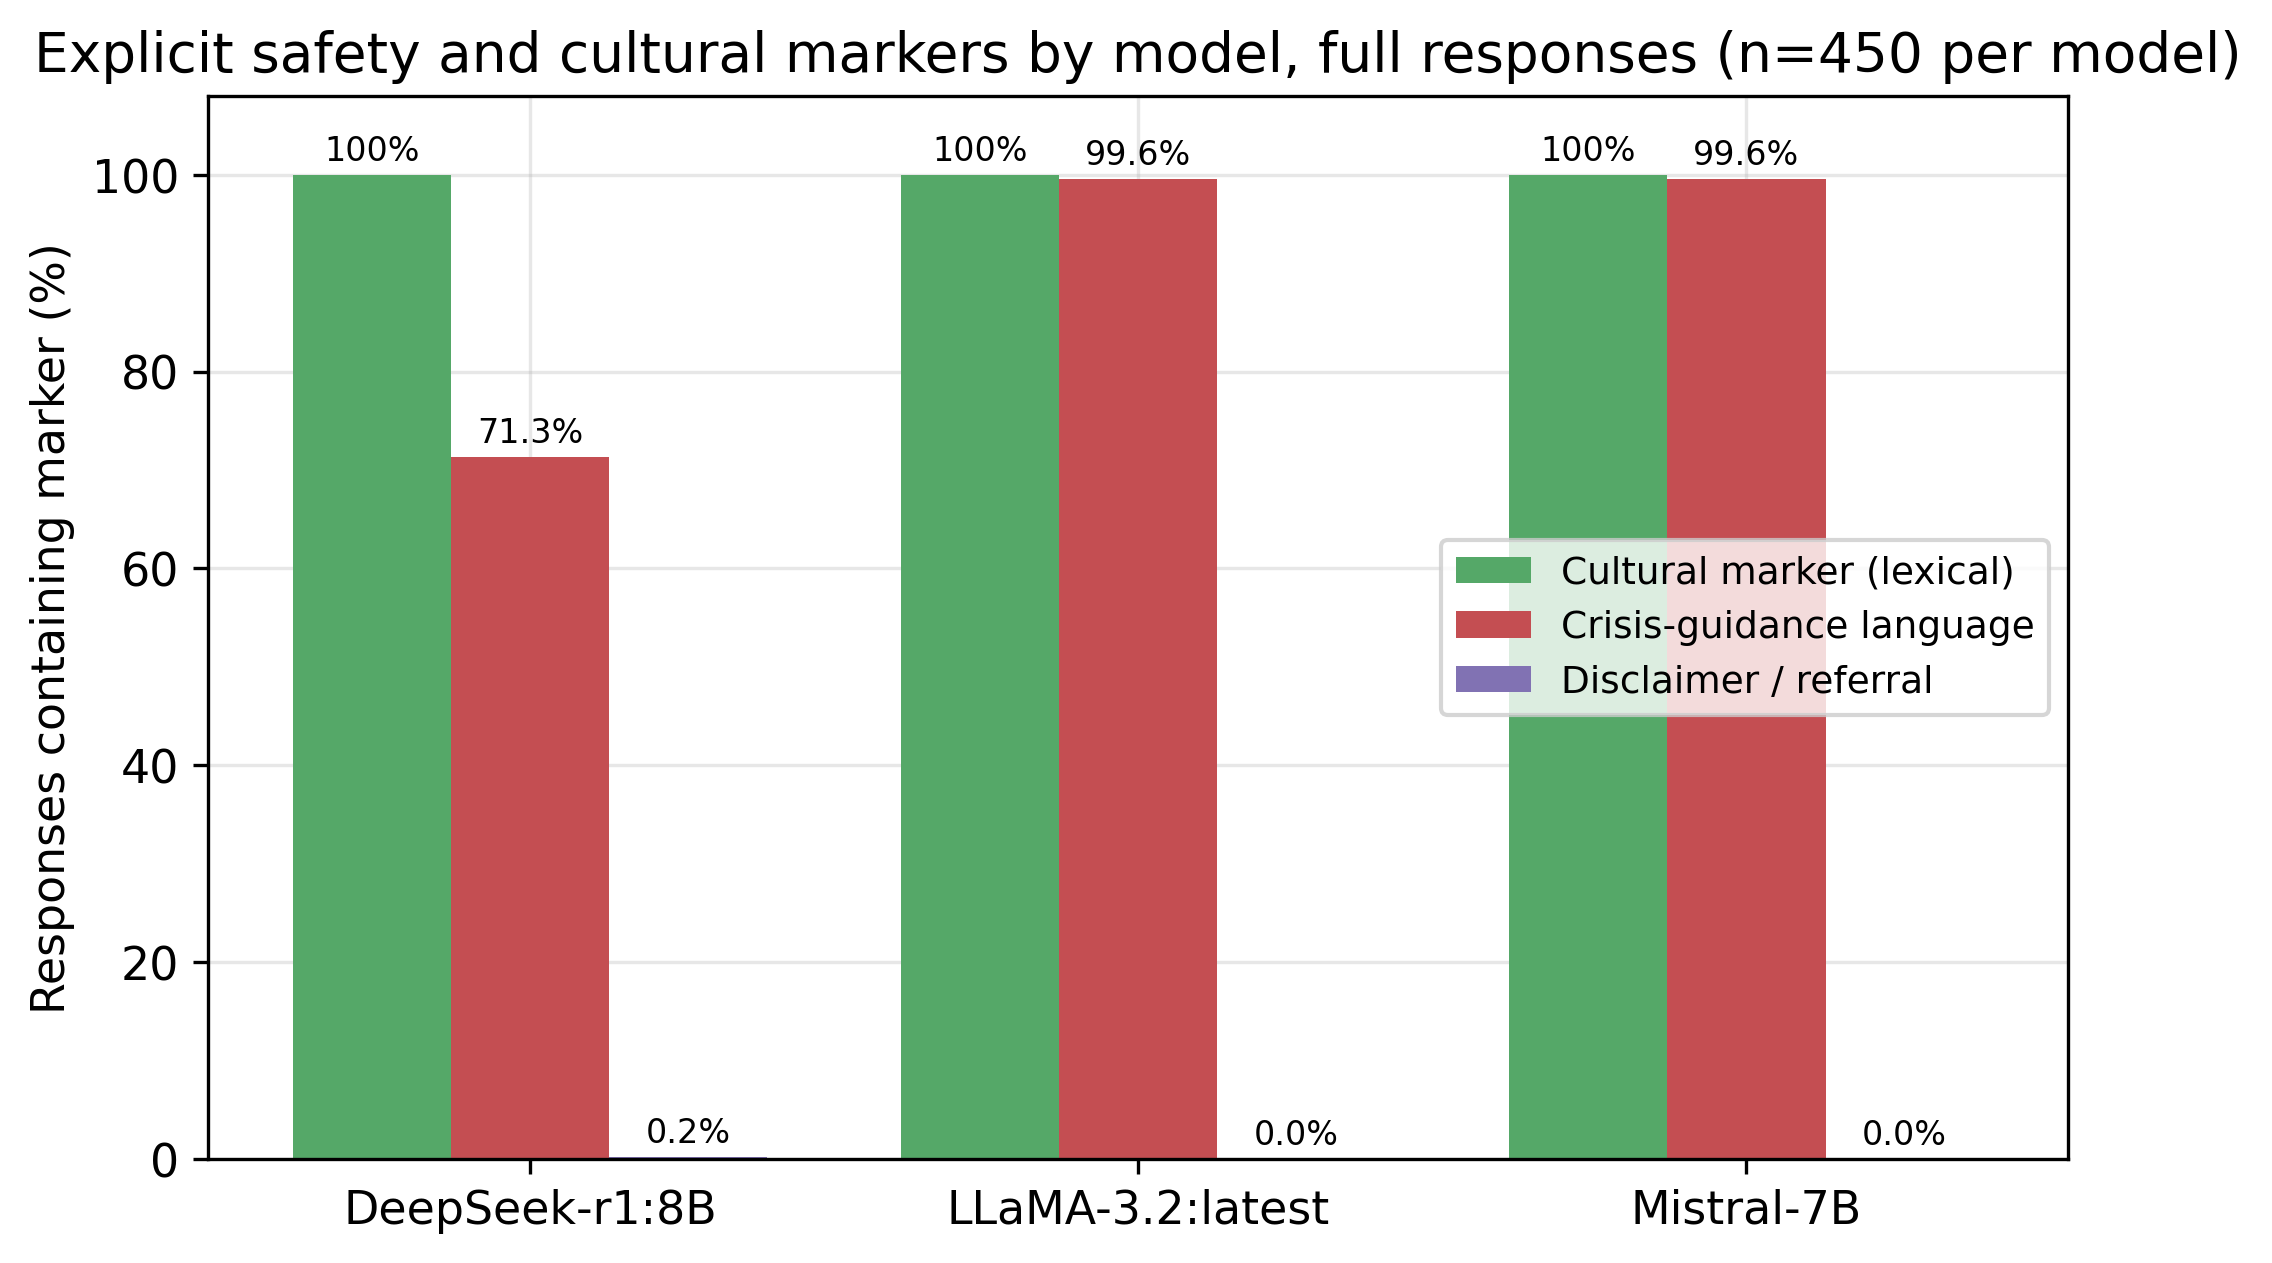

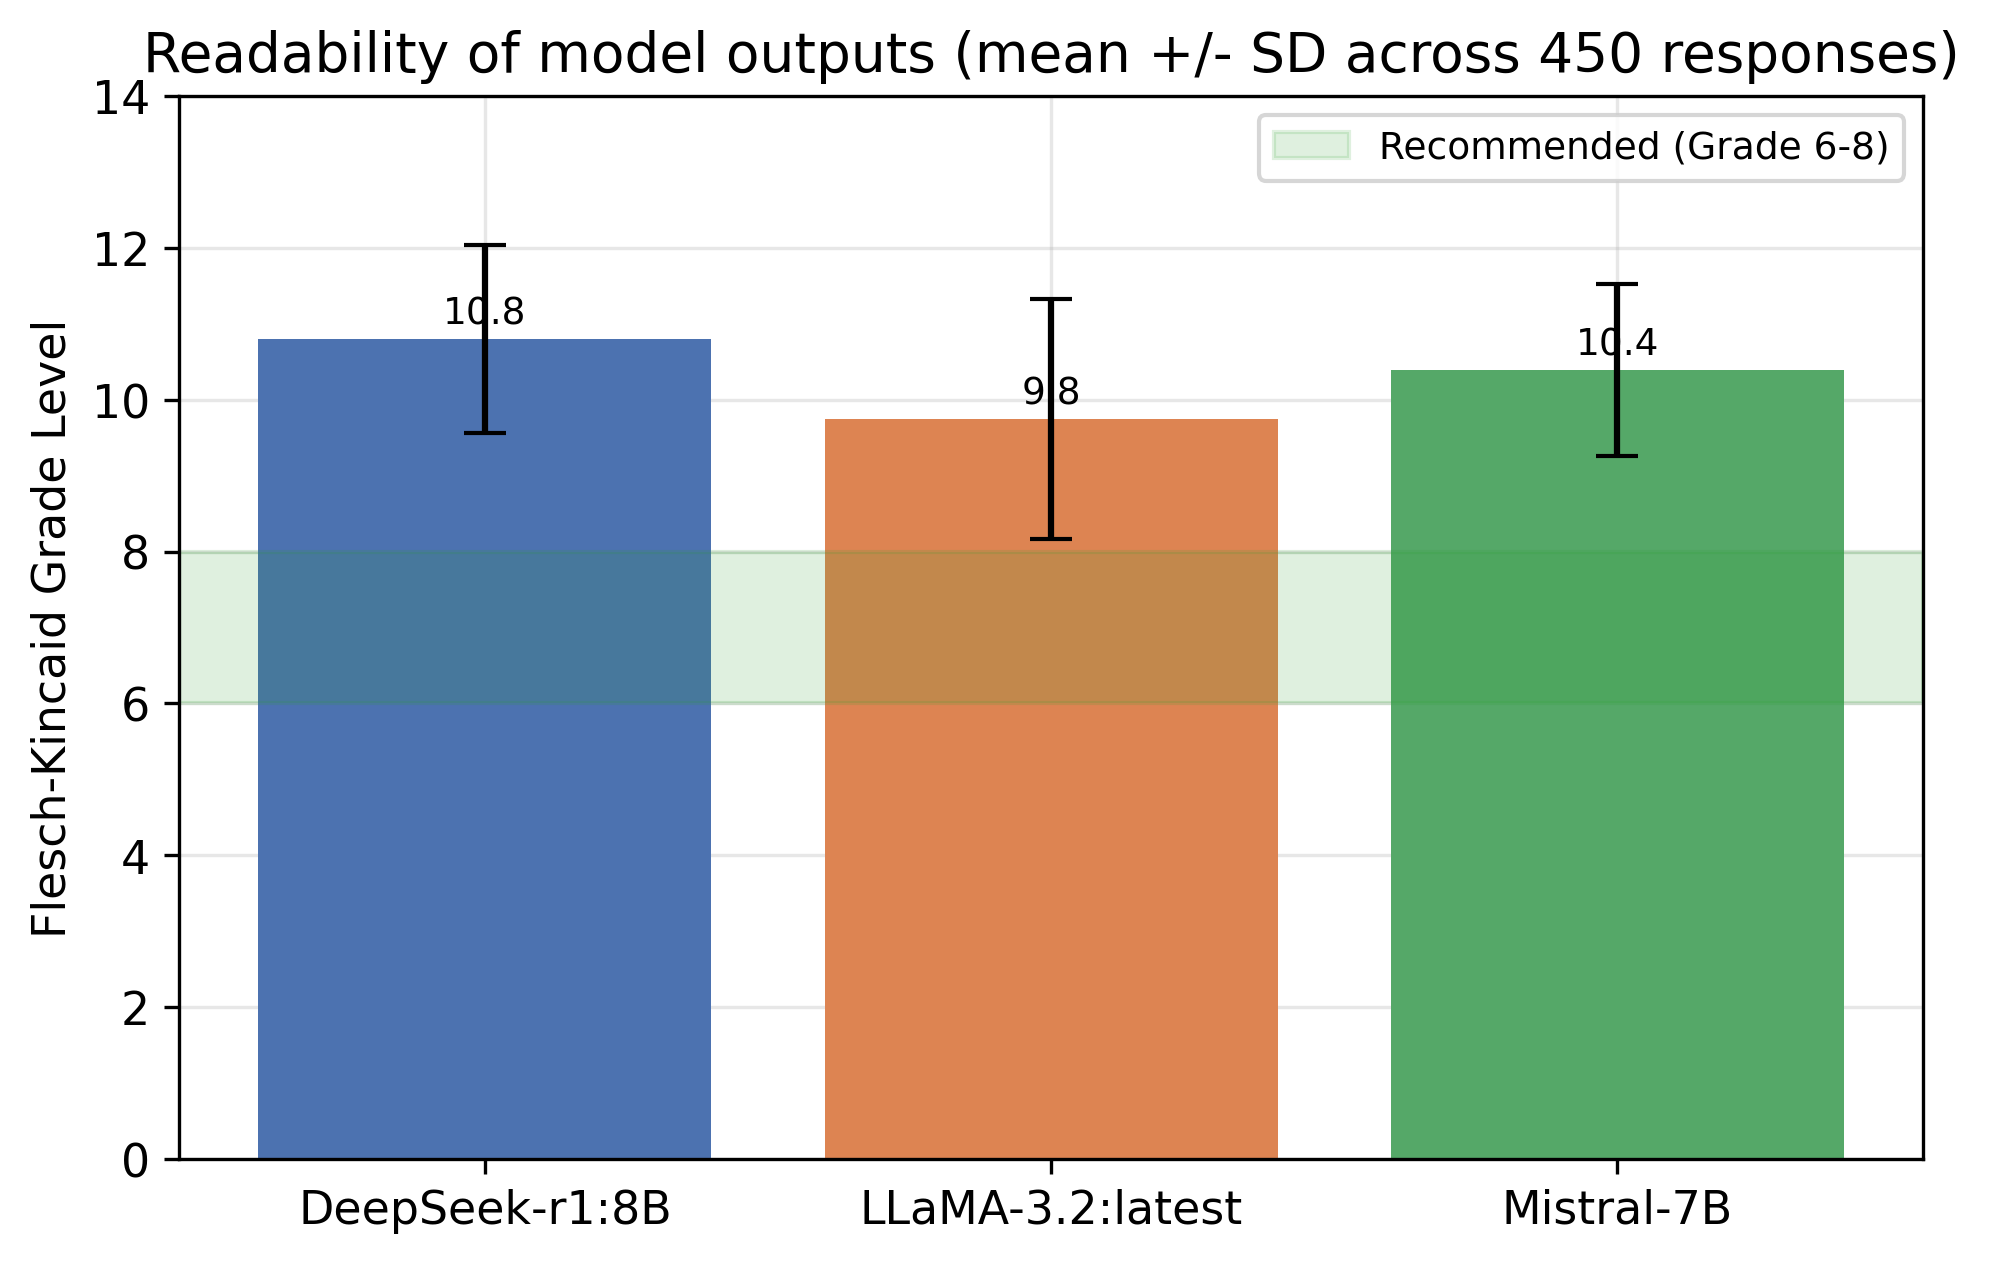

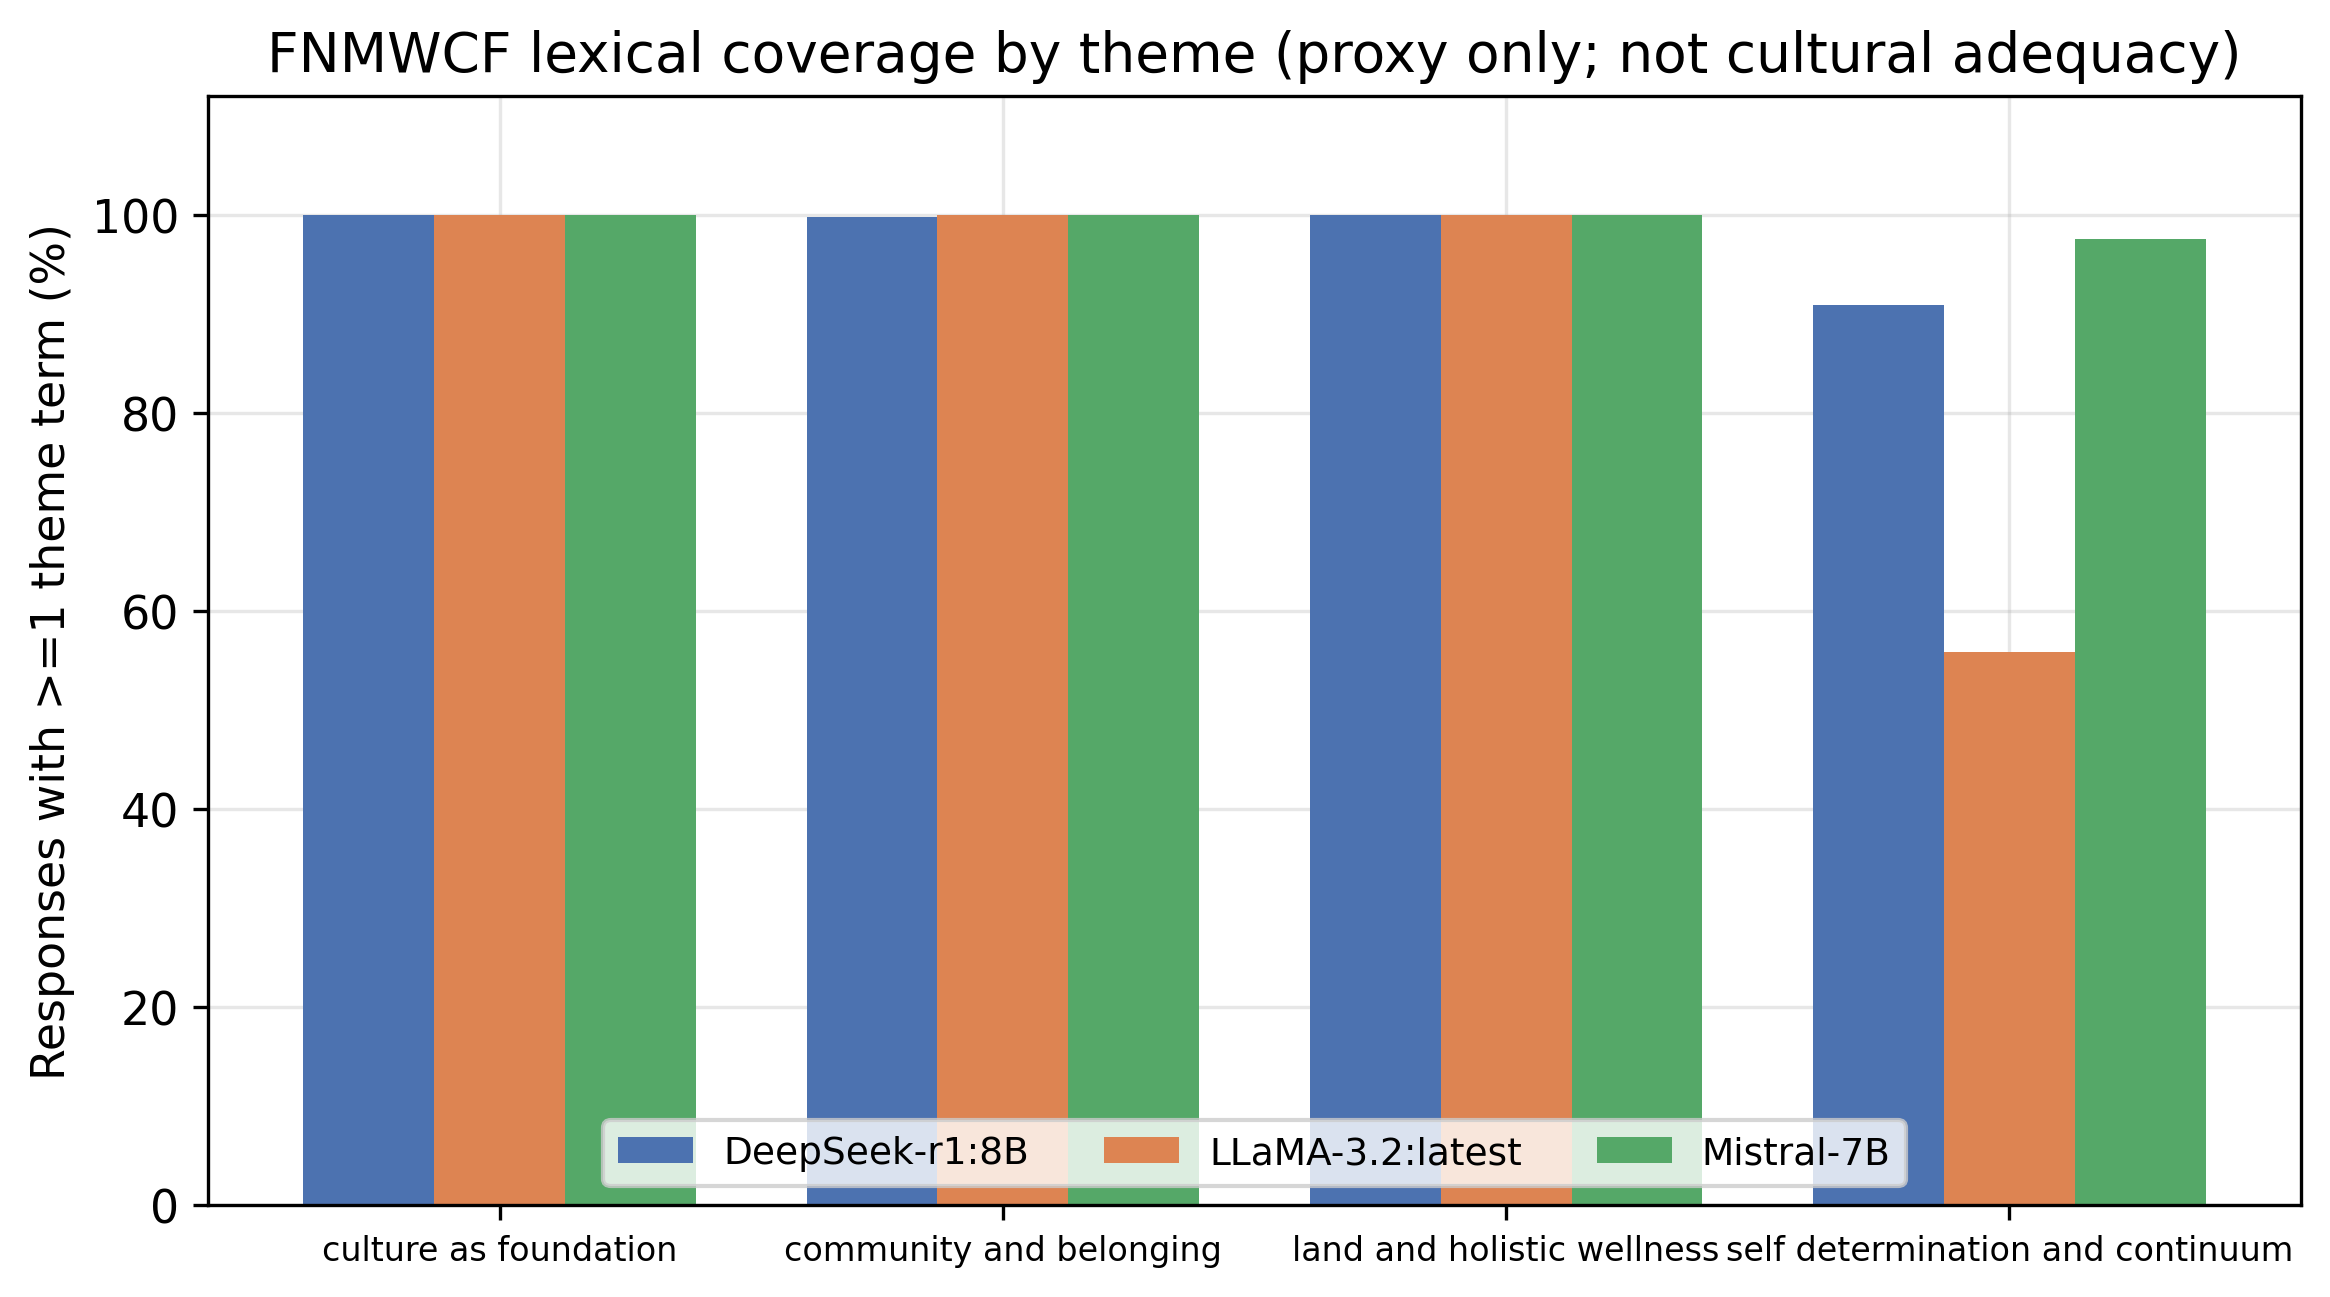

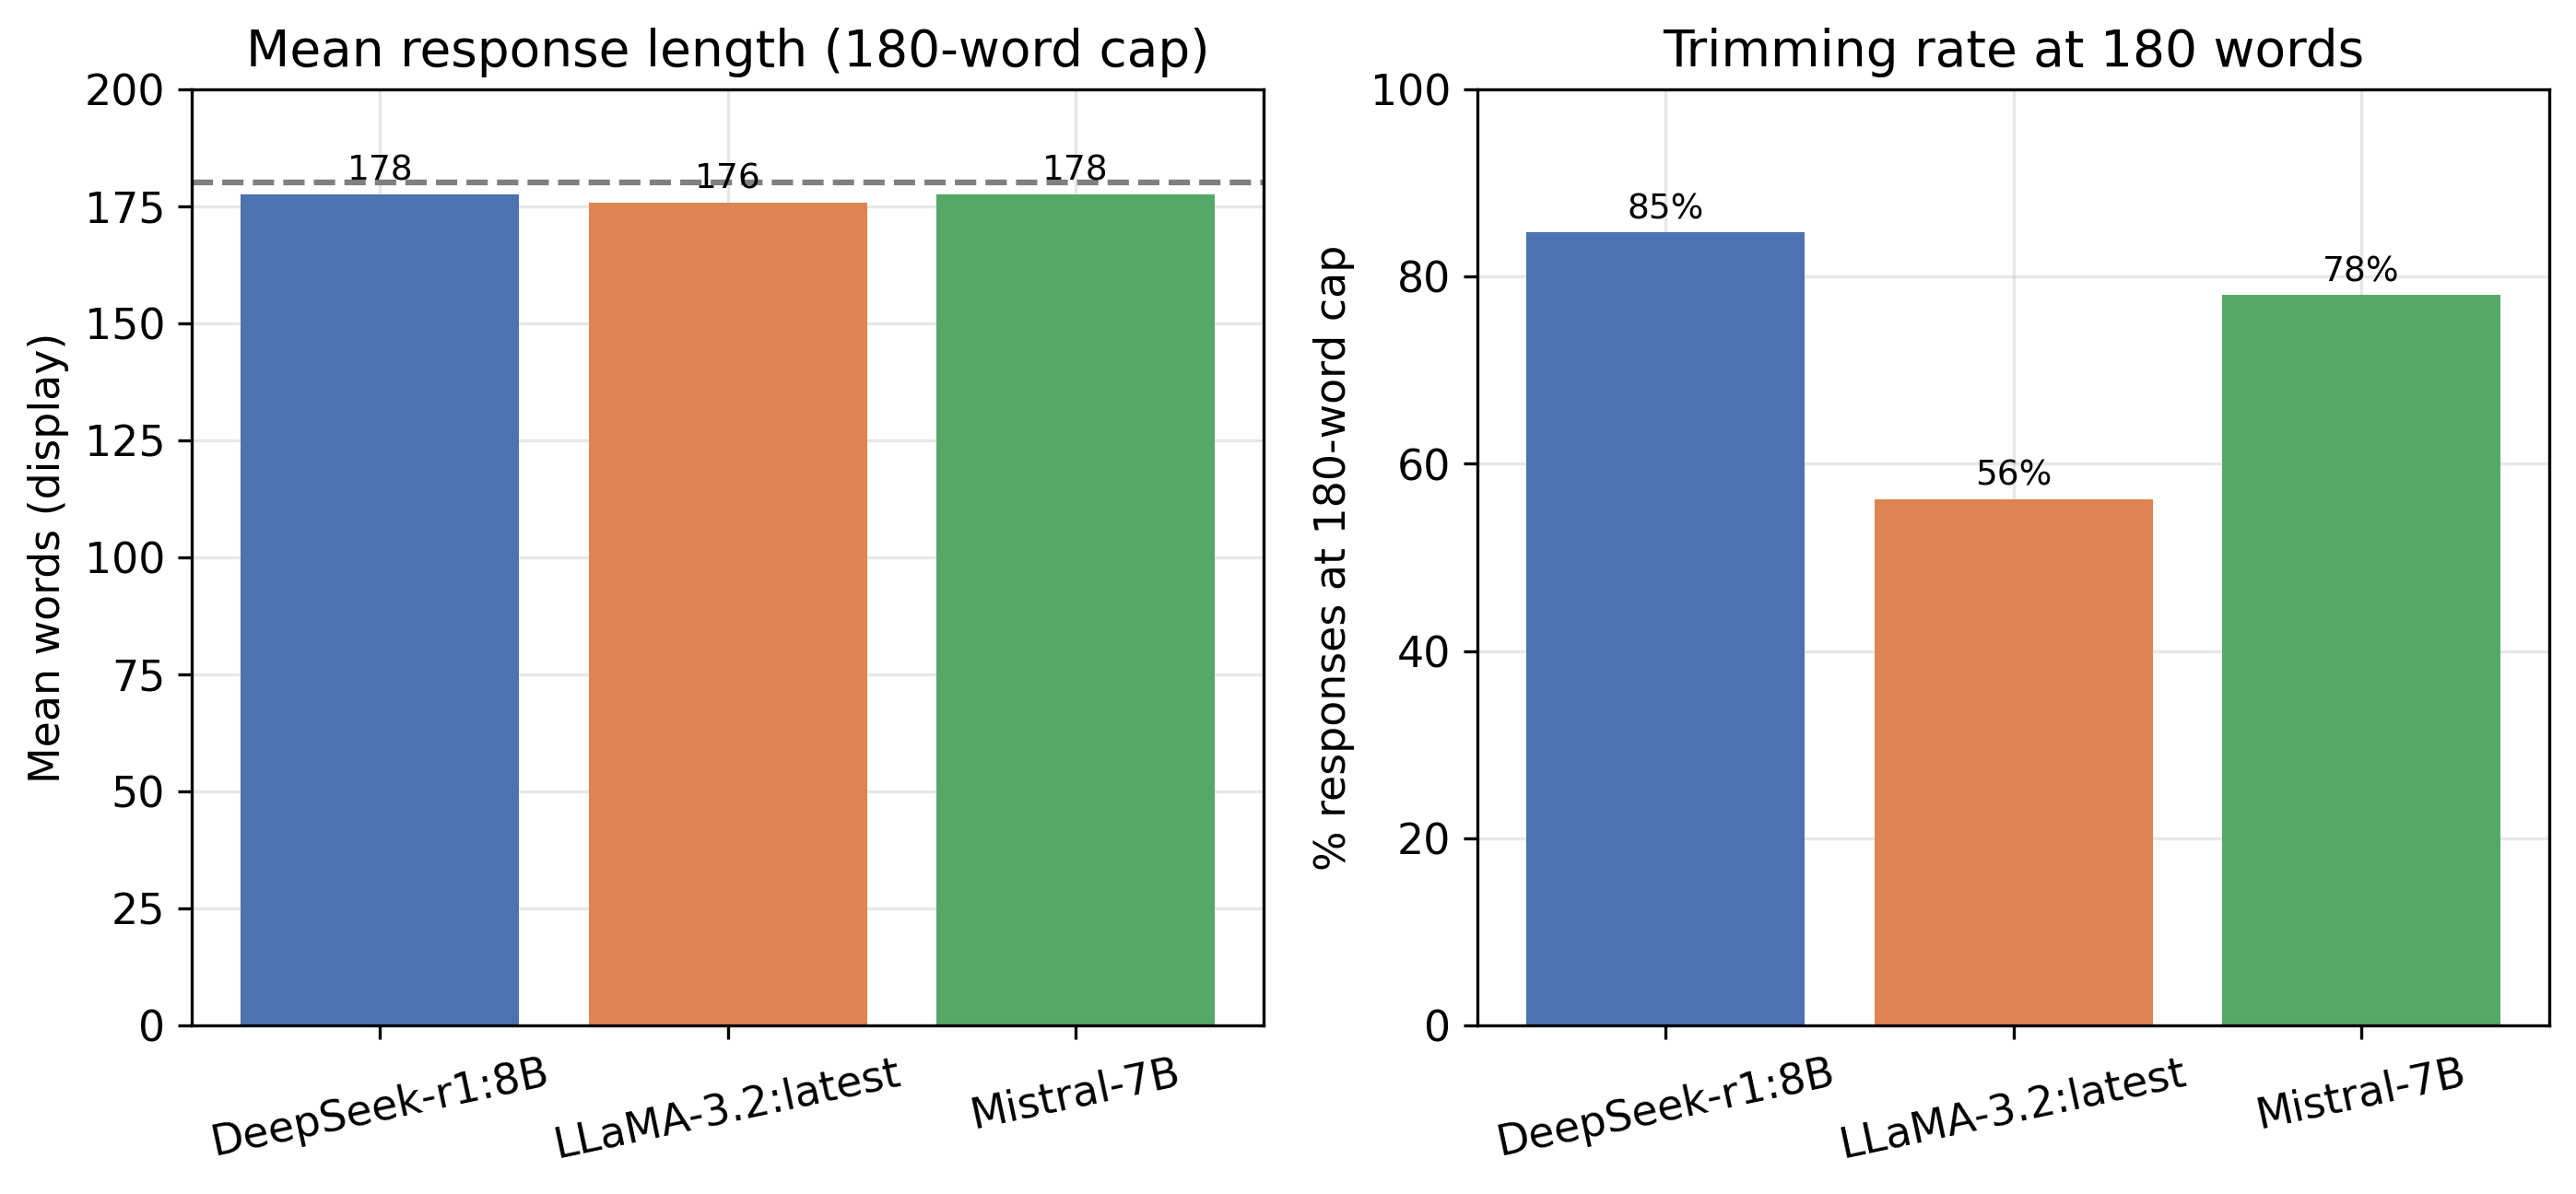

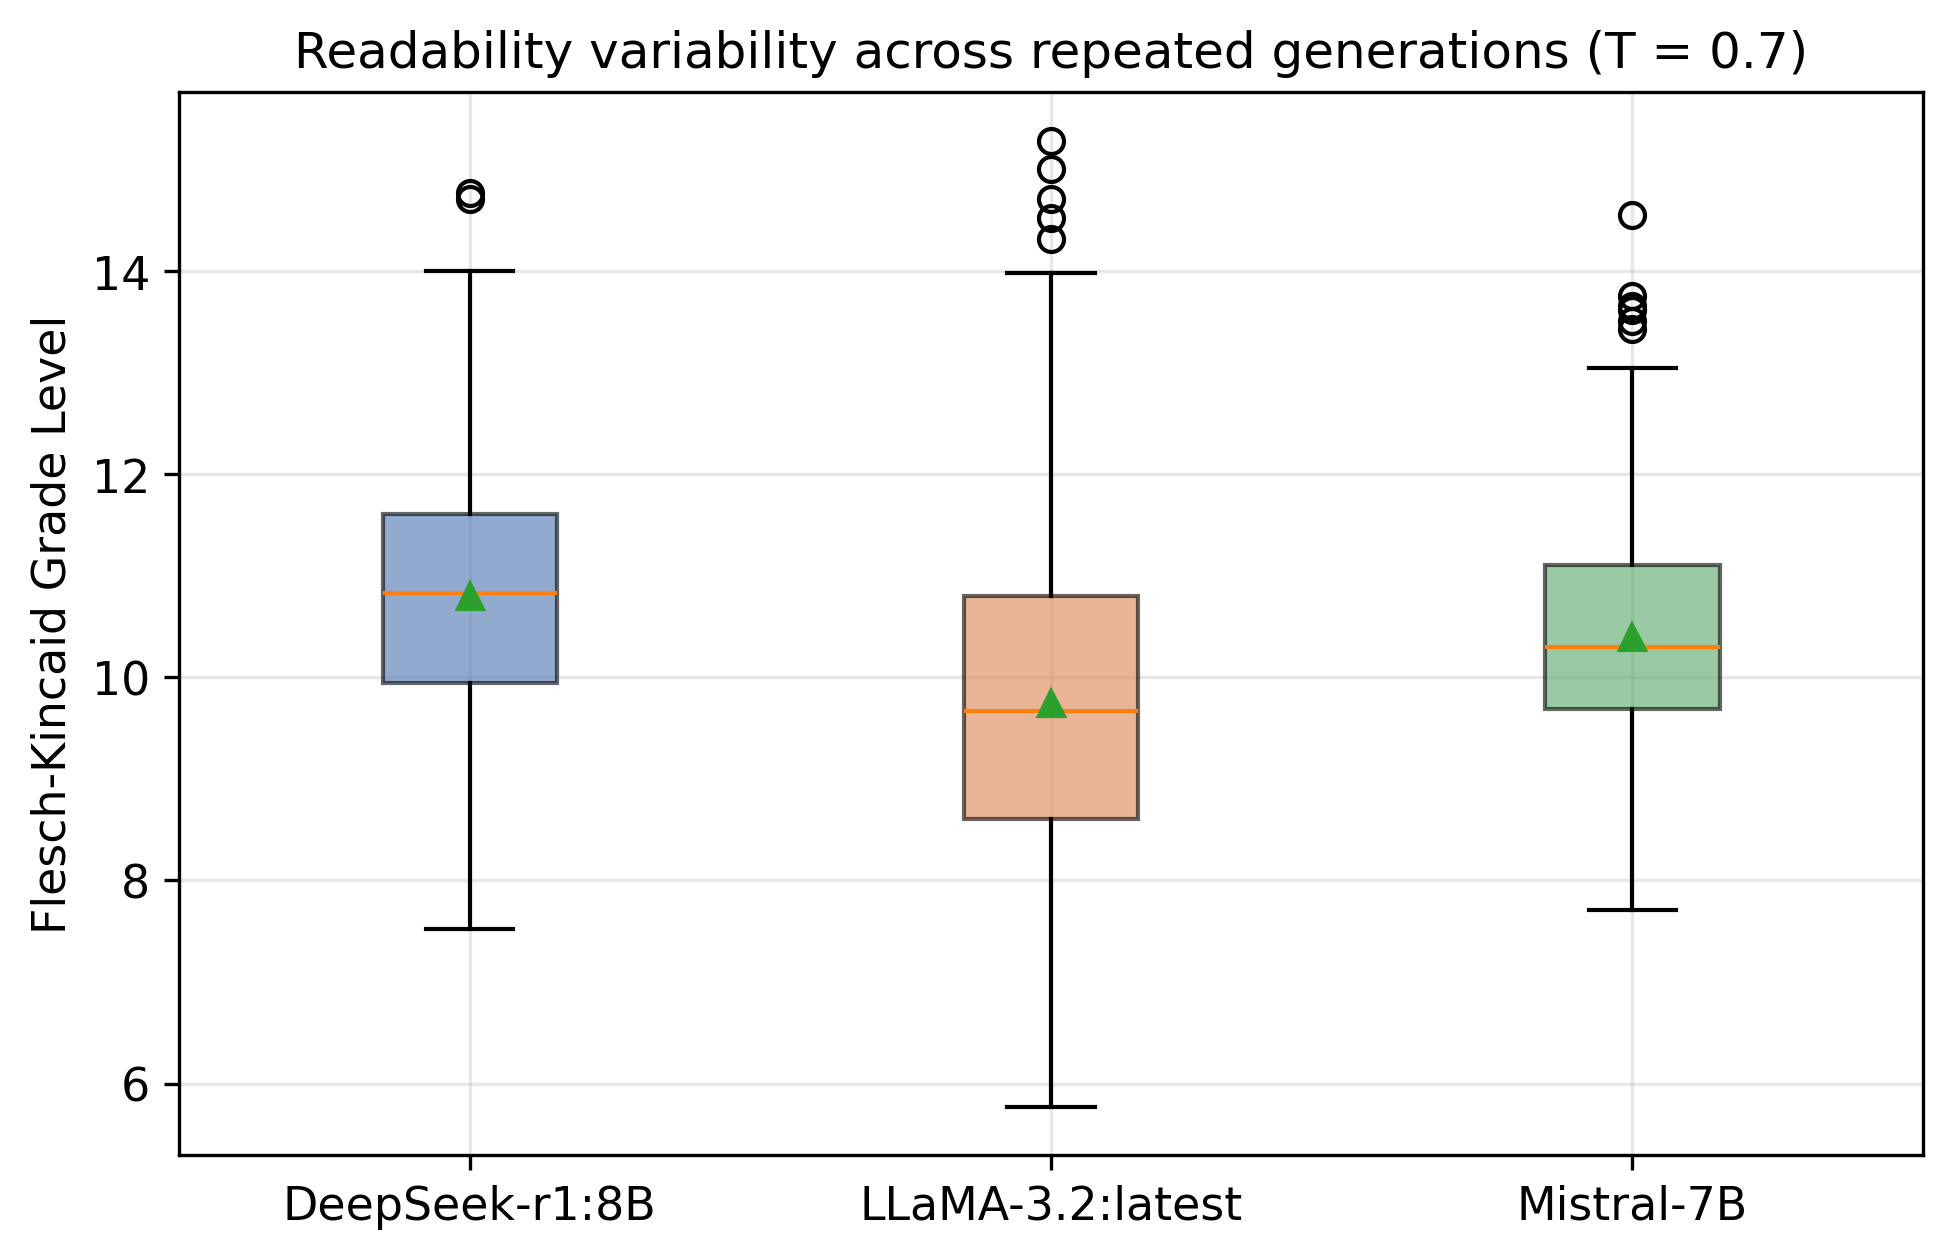

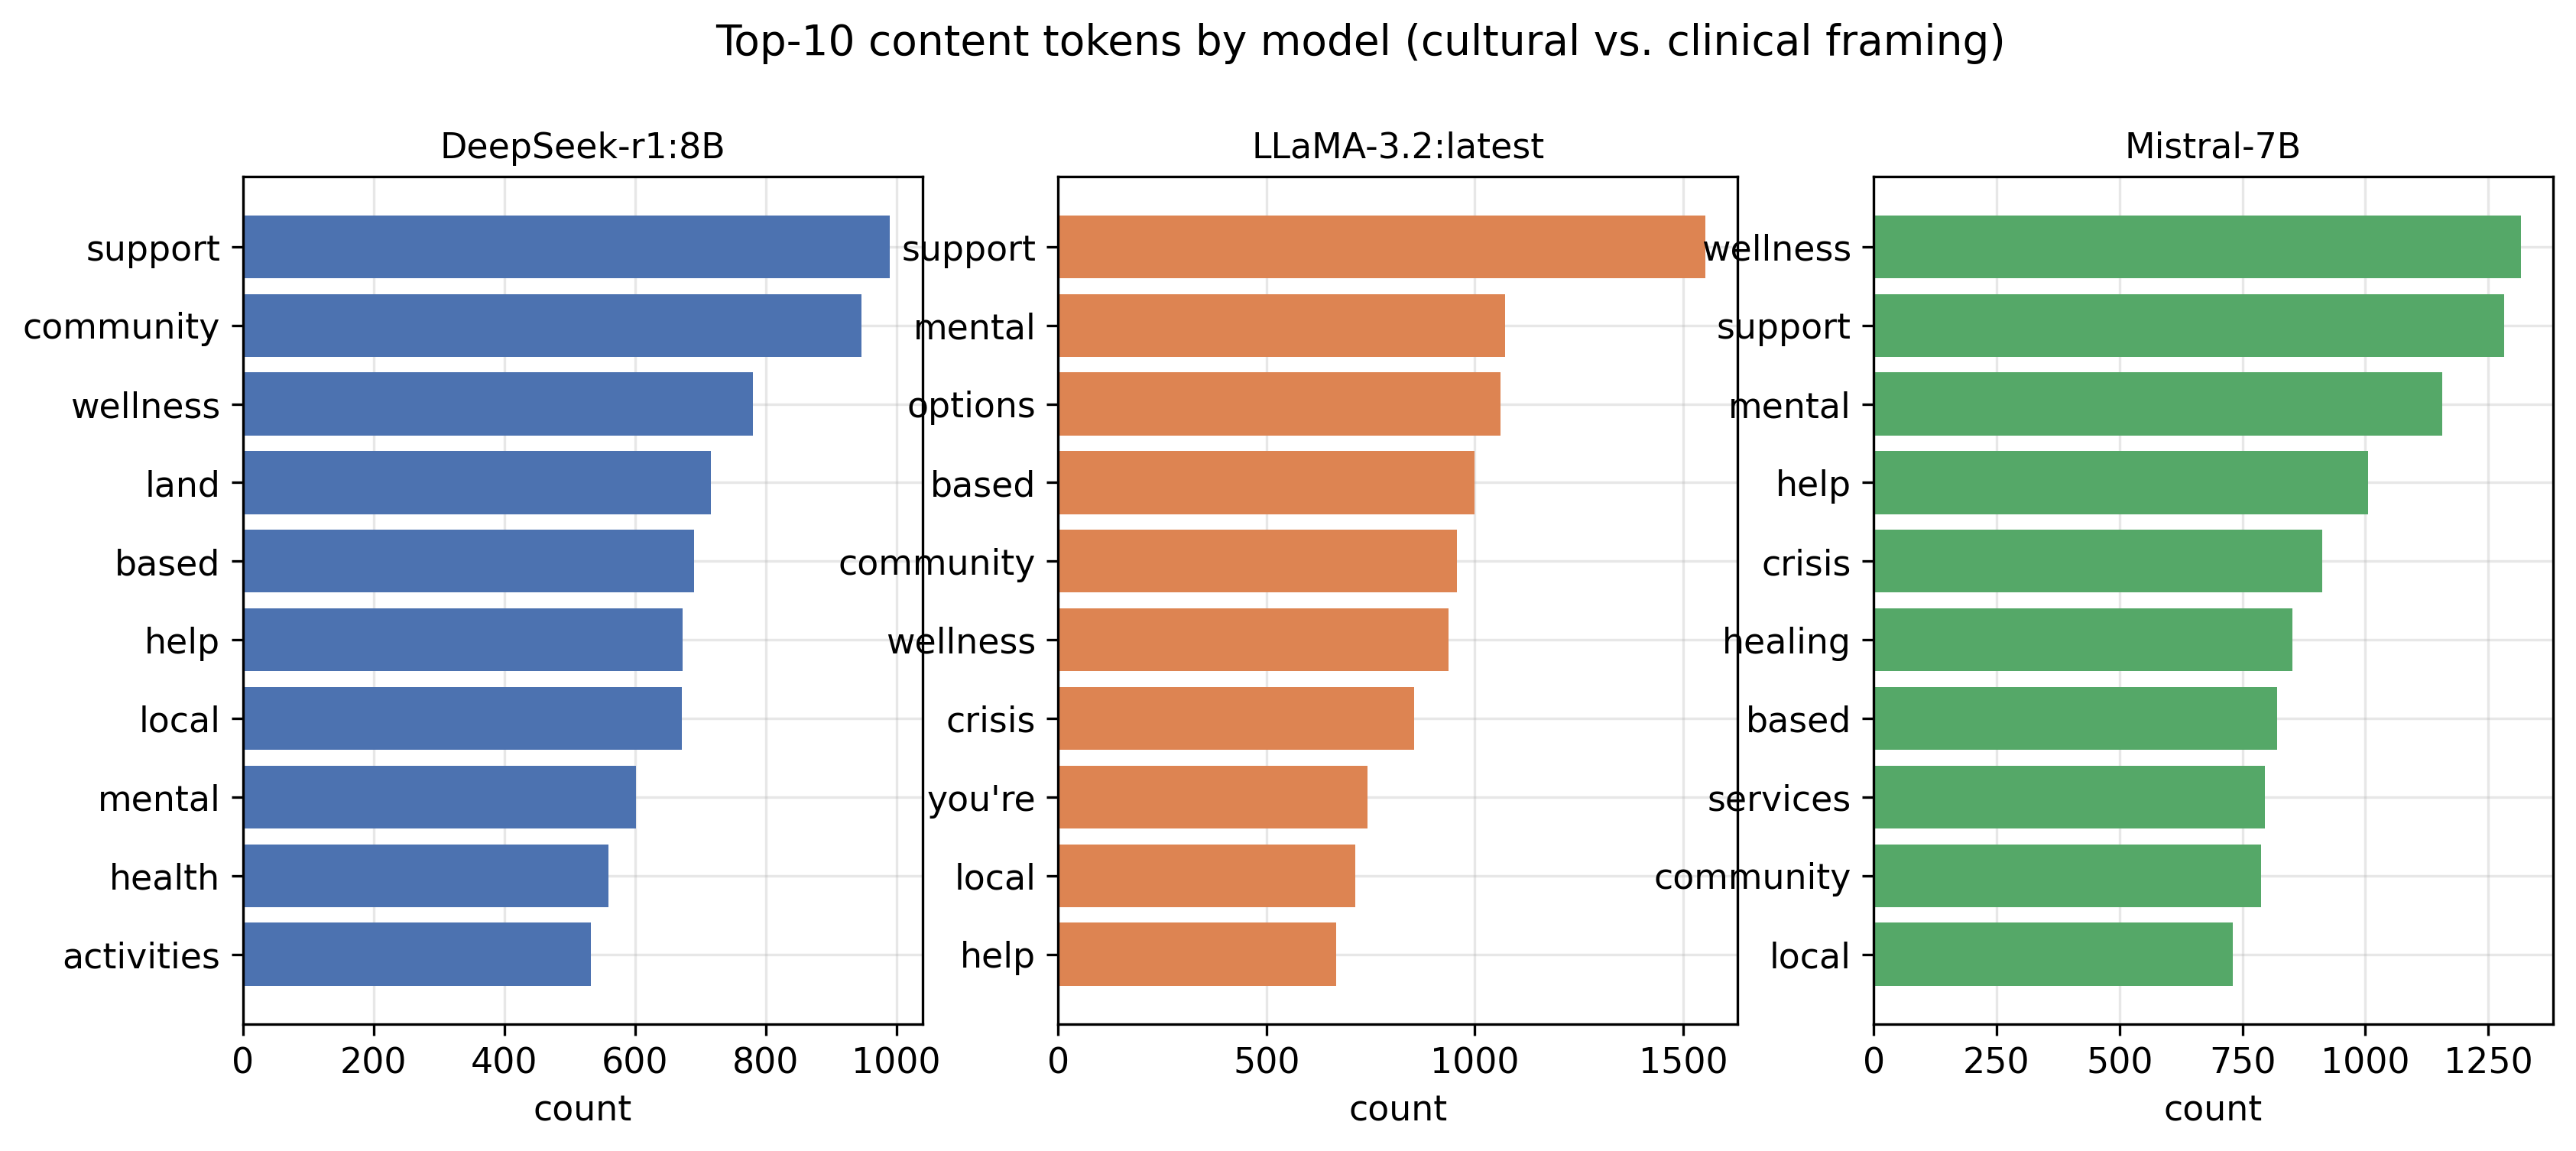

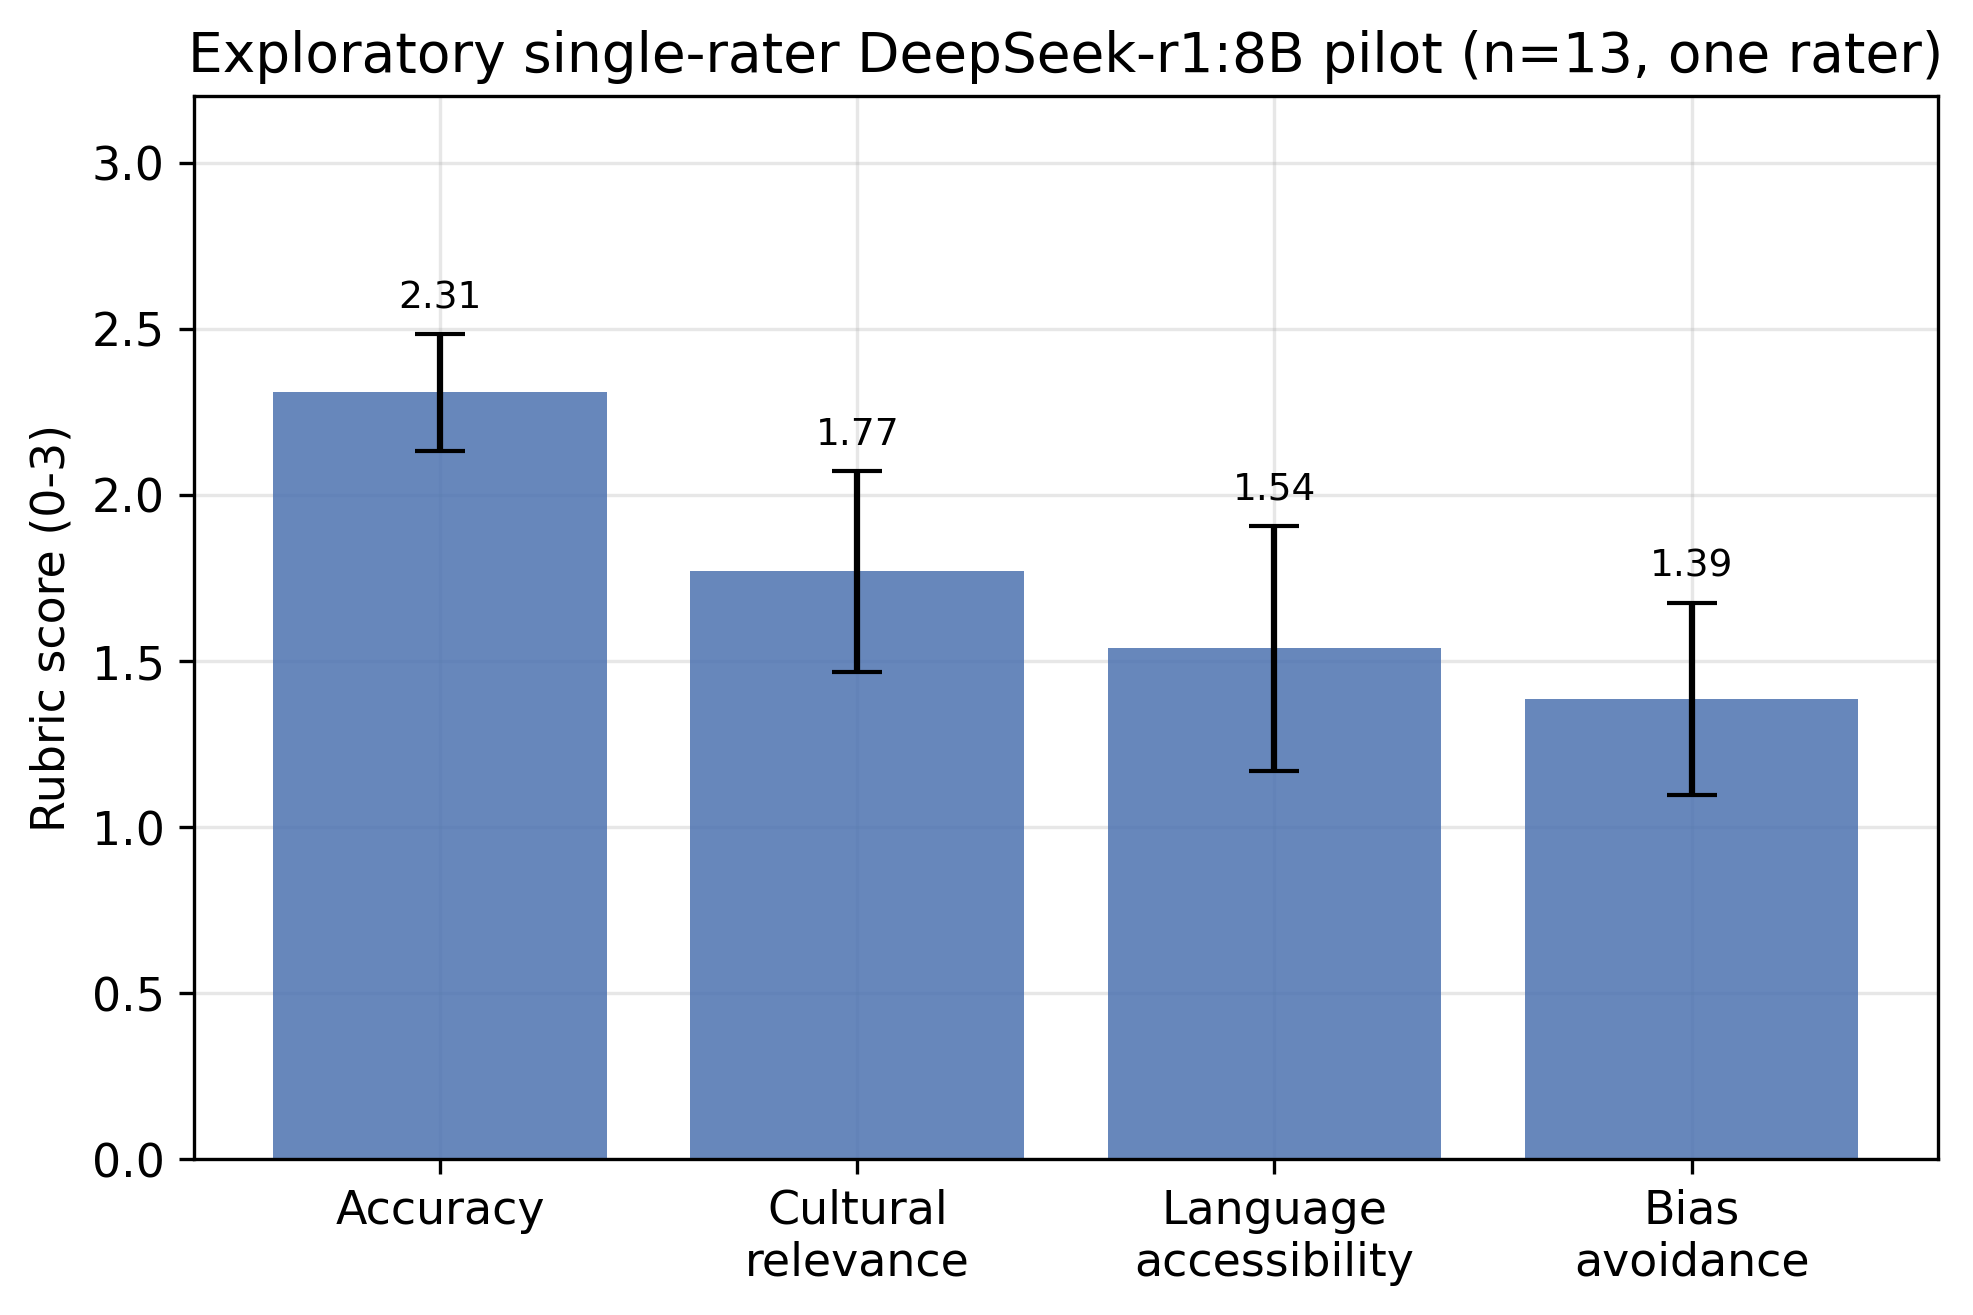

In [14]:
from IPython.display import Image, display
figures = rla.generate_all_figures(resp, ratings, cfg)
for name in rla.EXPECTED_FIGURES:
    display(Image(filename=str(figures[name])))

## 15. Validate computed values against the expected manuscript results

In [15]:
res = rla.validate(resp, prompts, ratings, cfg)
problems = rla.check_outputs_present(cfg, list(tables.keys()))
rla.write_report(res, problems, cfg)
for c in res.checks:
    print(("ok " if c.ok else "XX "), c.name, "obs=", c.observed, "exp=", c.expected)
print("value checks passed:", res.passed, "| output problems:", problems or "none")

ok  total_responses obs= 1350 exp= 1350
ok  responses[DeepSeek-r1:8B] obs= 450 exp= 450
ok  responses[LLaMA-3.2:latest] obs= 450 exp= 450
ok  responses[Mistral-7B] obs= 450 exp= 450
ok  crisis_full[DeepSeek-r1:8B] obs= 0.713 exp= 0.713
ok  crisis_full[LLaMA-3.2:latest] obs= 0.996 exp= 0.996
ok  crisis_full[Mistral-7B] obs= 0.996 exp= 0.996
ok  disclaimer[DeepSeek-r1:8B] obs= 0.002 exp= 0.002
ok  disclaimer[LLaMA-3.2:latest] obs= 0.0 exp= 0.0
ok  disclaimer[Mistral-7B] obs= 0.0 exp= 0.0
ok  crisis_trim[DeepSeek-r1:8B] obs= 0.3 exp= 0.3
ok  crisis_trim[LLaMA-3.2:latest] obs= 0.976 exp= 0.976
ok  crisis_trim[Mistral-7B] obs= 0.969 exp= 0.969
ok  fkgl[DeepSeek-r1:8B] obs= 10.8 exp= 10.8
ok  fkgl[LLaMA-3.2:latest] obs= 9.75 exp= 9.8
ok  fkgl[Mistral-7B] obs= 10.39 exp= 10.4
ok  pilot_deepseek_n obs= 13 exp= 13
value checks passed: True | output problems: none


## 16. Final assertions (fail if any expected output is missing/empty)

In [16]:
missing = [f for f in rla.EXPECTED_FIGURES
           if not (cfg.path('outputs','figures',f).exists() and cfg.path('outputs','figures',f).stat().st_size > 5000)]
assert not missing, f"missing/empty figures: {missing}"
assert res.passed, "expected-value validation failed"
assert not problems, problems
print("ALL CHECKS PASSED — figures and tables regenerated and validated.")

ALL CHECKS PASSED — figures and tables regenerated and validated.
